In [6]:
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, LSTM, Embedding, Bidirectional

In [7]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to C:\Users\Regino Balogo
[nltk_data]     Jr\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Regino Balogo
[nltk_data]     Jr\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

Lets Laod The Datasets

Trainig Dataset

In [30]:
import pandas as pd
import re

# Load the raw lines
with open("train.txt", "r", encoding="utf-8") as f:
    lines = f.readlines()

# Parse text and label
texts = []
labels = []

for line in lines:
    parts = line.strip().rsplit(";", 1)  # split from the right
    if len(parts) == 2:
        text, label = parts
        cleaned_text = re.sub(r'[^a-zA-Z ]+', ' ', text).strip().lower()
        if cleaned_text:  # Only keep non-empty cleaned text
            texts.append(cleaned_text)
            labels.append(label.lower().strip())
    else:
        print("Unrecognized format:", line)

# Create DataFrame
df = pd.DataFrame({'text': texts, 'label': labels})
df.head()


,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


Validation Dataset

In [38]:
with open("val.txt", "r", encoding="utf-8") as f:
    val_lines = f.readlines()

val_texts = []
val_labels = []

for line in val_lines:
    parts = line.strip().rsplit(";", 1)
    if len(parts) == 2:
        text, label = parts
        val_texts.append(text)
        val_labels.append(label.strip().lower())

val_df = pd.DataFrame({"text": val_texts, "label": val_labels})
val_df.head()


,text,label
0,im feeling quite sad and sorry for myself but ...,sadness
1,i feel like i am still looking at a blank canv...,sadness
2,i feel like a faithful servant,love
3,i am just feeling cranky and blue,anger
4,i can have for a treat or if i am feeling festive,joy


Exploratory Data Analysis (EDA)

Sentence Lenghts

Max sentence length: 66
Avg sentence length: 19.17
Median sentence length: 17.0


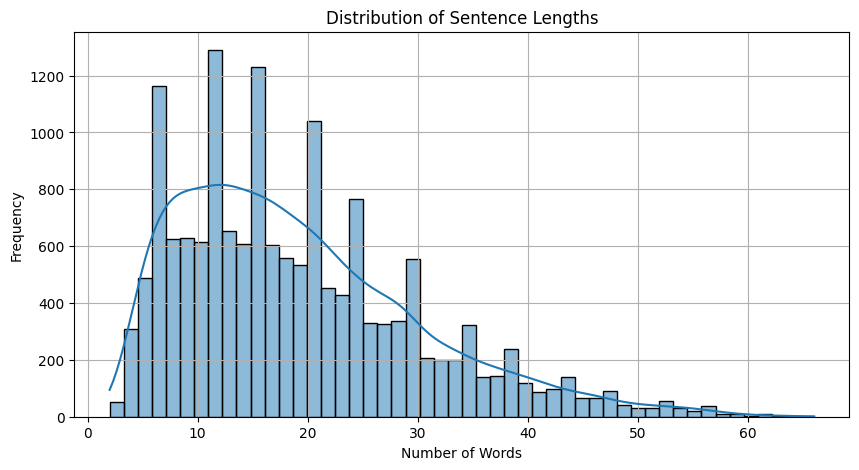

In [24]:
# Tokenize each sentence (basic whitespace split for now)
sentence_lengths = [len(sentence.split()) for sentence in texts]

# Statistics
import matplotlib.pyplot as plt
import seaborn as sns

print(f"Max sentence length: {max(sentence_lengths)}")
print(f"Avg sentence length: {np.mean(sentence_lengths):.2f}")
print(f"Median sentence length: {np.median(sentence_lengths)}")

# Plot
plt.figure(figsize=(10, 5))
sns.histplot(sentence_lengths, bins=50, kde=True)
plt.title("Distribution of Sentence Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


Most Common Words

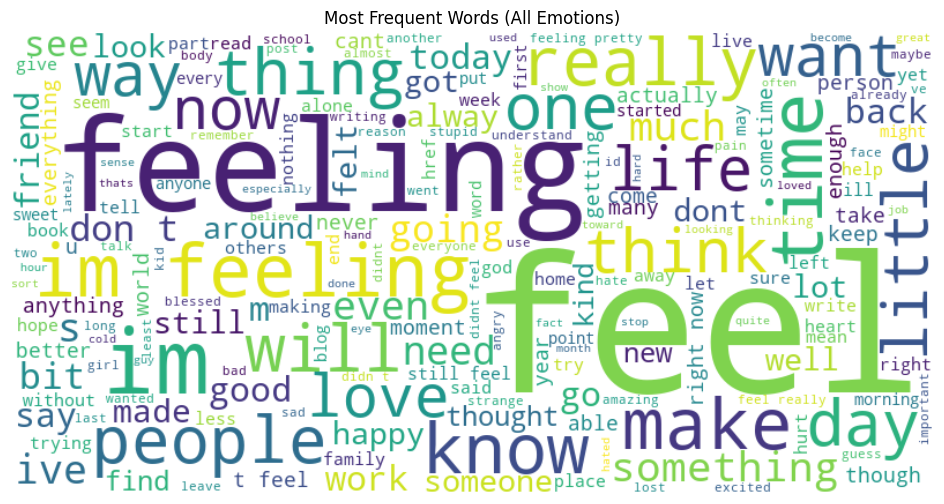

In [31]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

# Combine all text and clean it
all_text = ' '.join(df['text'].dropna()).lower()
all_text = re.sub(r'[^a-zA-Z ]+', ' ', all_text).strip()

if all_text:
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Most Frequent Words (All Emotions)")
    plt.show()
else:
    print("No valid text found for WordCloud.")


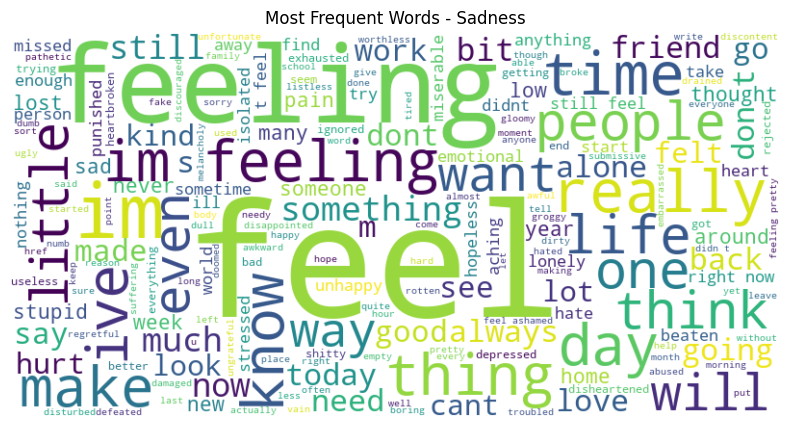

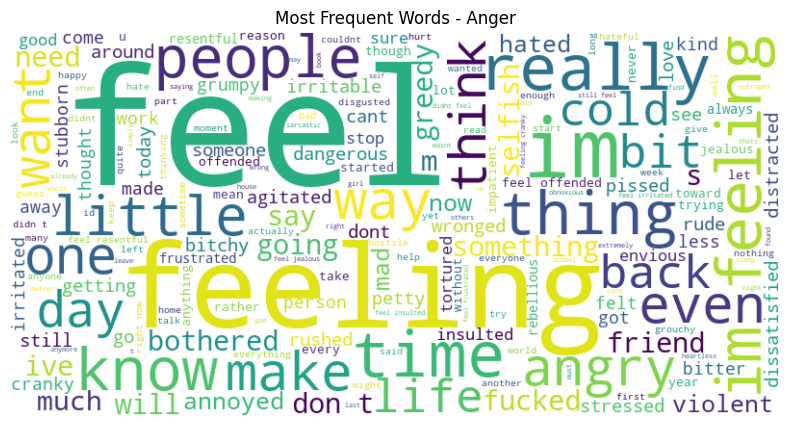

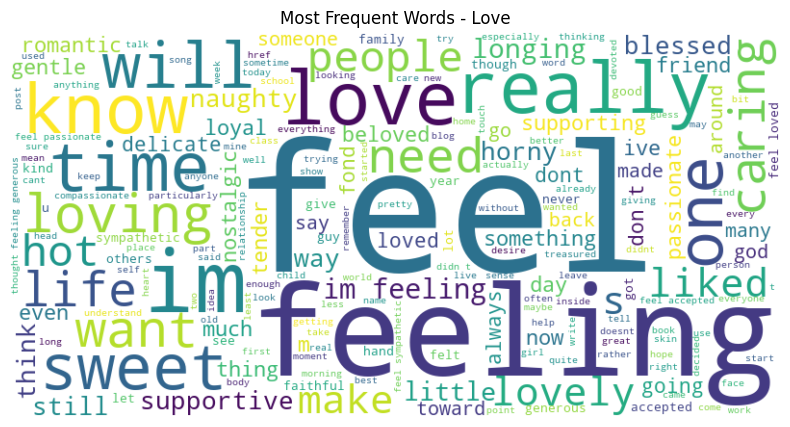

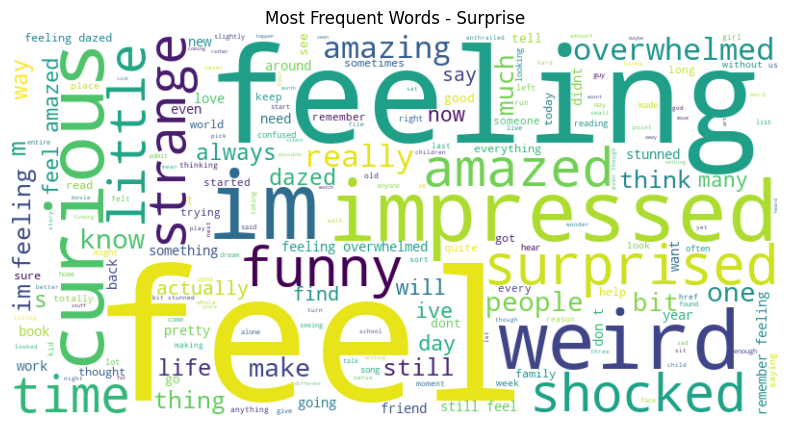

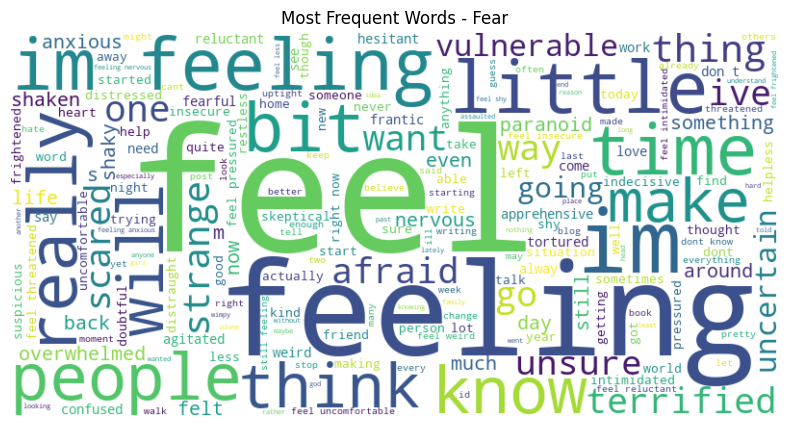

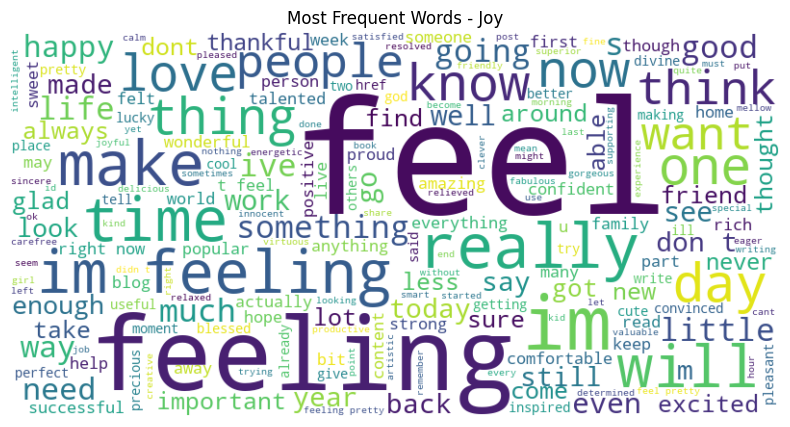

In [33]:
unique_labels = df['label'].unique()

for label in unique_labels:
    subset = df[df['label'] == label]['text'].dropna()
    label_text = ' '.join(subset).lower()
    label_text = re.sub(r'[^a-zA-Z ]+', ' ', label_text).strip()

    if label_text:
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(label_text)

        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f"Most Frequent Words - {label.capitalize()}")
        plt.show()
    else:
        print(f"No valid text found for label: {label}")


Bar Plot of Emotion/Class Distribution

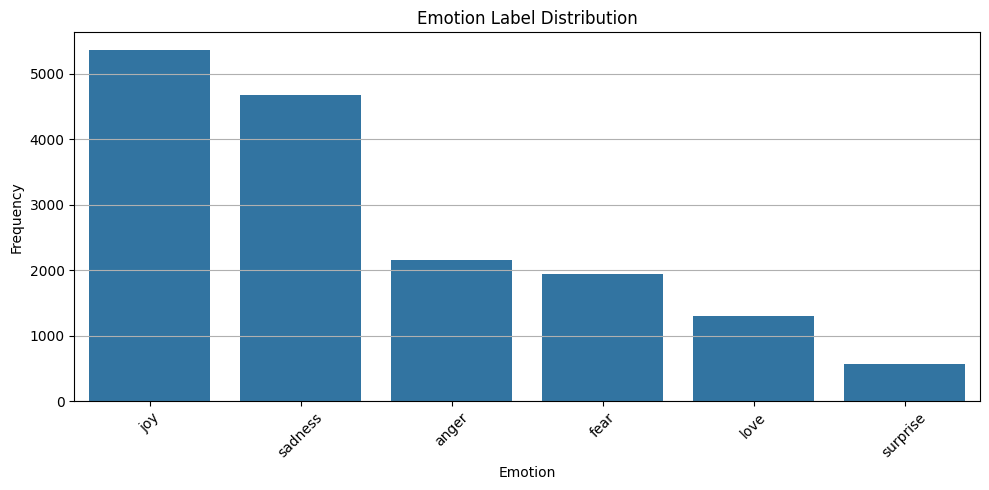

In [34]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.title("Emotion Label Distribution")
plt.xlabel("Emotion")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


Preprcessing Step

Step 1: Basic Cleaning - 
We remove all non-alphabetic characters and convert the text to lowercase.

In [8]:
def basic_clean(text):
    text = re.sub(r'[^a-zA-Z ]', '', text)  # Keep only letters and spaces
    text = text.lower()                     # Convert to lowercase
    text = re.sub(r'\s+', ' ', text).strip()# Remove extra whitespace
    return text


Step 2: Tokenization - We split the cleaned text into individual words (tokens).

In [9]:
def tokenize(text):
    return text.split()


Step 3 - Stopword Removal and Lemmatization

In [10]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def lemmatize_and_remove_stopwords(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]


Lets Apply To The Dataset

Preprocessing of Training Data

In [37]:
import pandas as pd

# Initialize a list to store the results
comparison_data = []

# Apply the steps on a sample of 5 texts (you can adjust this number)
sample_texts = df['text'].head(5)

# Loop through sample texts and apply preprocessing steps
for text in sample_texts:
    cleaned_text = basic_clean(text)
    tokens = tokenize(cleaned_text)
    processed_tokens = lemmatize_and_remove_stopwords(tokens)
    
    # Append results as a tuple
    comparison_data.append({
        'Original Text': text,
        'Cleaned Text': cleaned_text,
        'Tokenized Text': tokens,
        'Processed Tokens': processed_tokens
    })

# Convert the list to a DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Display the comparison table
comparison_df


,Original Text,Cleaned Text,Tokenized Text,Processed Tokens
0,i didnt feel humiliated,i didnt feel humiliated,"[i, didnt, feel, humiliated]","[didnt, feel, humiliated]"
1,i can go from feeling so hopeless to so damned...,i can go from feeling so hopeless to so damned...,"[i, can, go, from, feeling, so, hopeless, to, ...","[go, feeling, hopeless, damned, hopeful, aroun..."
2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong,"[im, grabbing, a, minute, to, post, i, feel, g...","[im, grabbing, minute, post, feel, greedy, wrong]"
3,i am ever feeling nostalgic about the fireplac...,i am ever feeling nostalgic about the fireplac...,"[i, am, ever, feeling, nostalgic, about, the, ...","[ever, feeling, nostalgic, fireplace, know, st..."
4,i am feeling grouchy,i am feeling grouchy,"[i, am, feeling, grouchy]","[feeling, grouchy]"


Preprocessing of Validation Data

In [40]:
# Sample validation data (you can adjust this number)
sample_val_texts = val_df['text'].head(5)

# Initialize a list to store the results
val_comparison_data = []

# Apply the steps on the sample of 5 texts
for text in sample_val_texts:
    cleaned_text = basic_clean(text)
    tokens = tokenize(cleaned_text)
    processed_tokens = lemmatize_and_remove_stopwords(tokens)
    
    # Append results as a dictionary
    val_comparison_data.append({
        'Original Text': text,
        'Cleaned Text': cleaned_text,
        'Tokenized Text': tokens,
        'Processed Tokens': processed_tokens
    })

# Convert the list to a DataFrame
val_comparison_df = pd.DataFrame(val_comparison_data)

# Display the comparison table
val_comparison_df


,Original Text,Cleaned Text,Tokenized Text,Processed Tokens
0,im feeling quite sad and sorry for myself but ...,im feeling quite sad and sorry for myself but ...,"[im, feeling, quite, sad, and, sorry, for, mys...","[im, feeling, quite, sad, sorry, ill, snap, soon]"
1,i feel like i am still looking at a blank canv...,i feel like i am still looking at a blank canv...,"[i, feel, like, i, am, still, looking, at, a, ...","[feel, like, still, looking, blank, canvas, bl..."
2,i feel like a faithful servant,i feel like a faithful servant,"[i, feel, like, a, faithful, servant]","[feel, like, faithful, servant]"
3,i am just feeling cranky and blue,i am just feeling cranky and blue,"[i, am, just, feeling, cranky, and, blue]","[feeling, cranky, blue]"
4,i can have for a treat or if i am feeling festive,i can have for a treat or if i am feeling festive,"[i, can, have, for, a, treat, or, if, i, am, f...","[treat, feeling, festive]"


Now lets train the model

First we need to Vectorize the Text Data

In [42]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Parameters for padding and tokenization
MAX_SEQUENCE_LENGTH = 100  # Set max sequence length
MAX_NUM_WORDS = 10000  # Set maximum number of words to use in the tokenizer

# Initialize the tokenizer
tokenizer = Tokenizer(num_words=MAX_NUM_WORDS)

# Fit tokenizer on the training data
tokenizer.fit_on_texts(df['text'])

# Convert texts to sequences
X_train = tokenizer.texts_to_sequences(df['text'])
X_val = tokenizer.texts_to_sequences(val_df['text'])  # Assuming val_df is your validation data
X_test = tokenizer.texts_to_sequences(test_df['text'])  # Assuming test_df is your test data

# Pad sequences to ensure equal length
X_train_padded = pad_sequences(X_train, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_val_padded = pad_sequences(X_val, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
X_test_padded = pad_sequences(X_test, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

# Display the shape of the padded sequences to ensure correctness
print(f"Training data shape: {X_train_padded.shape}")
print(f"Validation data shape: {X_val_padded.shape}")
print(f"Test data shape: {X_test_padded.shape}")


Training data shape: (16000, 100)
Validation data shape: (2000, 100)
Test data shape: (2000, 100)


Converting Labels to Numeric Values

In [44]:
from sklearn.preprocessing import LabelEncoder

# Initialize the label encoder
label_encoder = LabelEncoder()

# Fit the encoder on the train data labels
y_train = label_encoder.fit_transform(df['label'])
y_val = label_encoder.transform(val_df['label'])  # Transform the validation data labels

# Display the label encoding mapping
label_mapping = dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))
print("Label encoding mapping:", label_mapping)

# Verify the conversion by displaying the first few labels from train and validation datasets
print(f"Encoded labels for the first 5 samples in train data: {y_train[:5]}")
print(f"Encoded labels for the first 5 samples in validation data: {y_val[:5]}")


Label encoding mapping: {'anger': 0, 'fear': 1, 'joy': 2, 'love': 3, 'sadness': 4, 'surprise': 5}
Encoded labels for the first 5 samples in train data: [4 4 0 3 0]
Encoded labels for the first 5 samples in validation data: [4 4 3 0 2]


In [53]:
import numpy as np

path_to_glove_file = 'glove.6B.100d.txt'
embedding_dim = 100  # Dimensions of GloVe (50, 100, 200, or 300 depending on file used)

# Build the embedding index (word -> vector)
embeddings_index = {}
with open(path_to_glove_file, encoding='utf-8') as f:
    for line in f:
        word, coefs = line.strip().split(maxsplit=1)
        coefs = np.fromstring(coefs, dtype='float32', sep=' ')
        embeddings_index[word] = coefs

print(f"Found {len(embeddings_index)} word vectors in GloVe.")


Found 400000 word vectors in GloVe.


In [54]:
vocab_size = min(MAX_NUM_WORDS, len(tokenizer.word_index) + 1)

# Prepare embedding matrix
embedding_matrix = np.zeros((vocab_size, embedding_dim))
hits = 0
misses = 0

for word, i in tokenizer.word_index.items():
    if i >= vocab_size:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        misses += 1

print(f"Converted {hits} words ({misses} misses)")


Converted 9630 words (369 misses)


Now let's Build and Train the LSTM Model

In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential()
model.add(Embedding(
    input_dim=vocab_size,                  # total number of tokens (rows in embedding_matrix)
    output_dim=embedding_dim,             # dimension of GloVe vectors (200 here)
    input_length=X_train_padded.shape[1], # max sequence length
    weights=[embedding_matrix],           # initialize with GloVe
    trainable=False                       # freeze GloVe weights
))
model.add(Bidirectional(LSTM(256, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)))
model.add(Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)))
model.add(Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)))
model.add(Dense(6, activation='softmax'))  # 6 classes of emotions

# Compile
model.compile(loss='categorical_crossentropy', optimizer=Adam(0.005), metrics=['accuracy'])
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

In [56]:
from tensorflow.keras.utils import to_categorical

# y_train and y_val are integer labels (e.g., 0–5), we need to one-hot encode them
y_train_cat = to_categorical(y_train, num_classes=6)
y_val_cat = to_categorical(y_val, num_classes=6)


In [57]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [58]:
history = model.fit(
    X_train_padded, y_train_cat,
    validation_data=(X_val_padded, y_val_cat),
    batch_size=256,
    epochs=10,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 615s 9s/step - accuracy: 0.3072 - loss: 1.6216 - val_accuracy: 0.4440 - val_loss: 1.4948
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 430s 7s/step - accuracy: 0.4871 - loss: 1.3816 - val_accuracy: 0.5705 - val_loss: 1.1336
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 404s 6s/step - accuracy: 0.5533 - loss: 1.1542 - val_accuracy: 0.6485 - val_loss: 0.9184
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 443s 7s/step - accuracy: 0.6667 - loss: 0.8912 - val_accuracy: 0.7745 - val_loss: 0.6150
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 492s 8s/step - accuracy: 0.7992 - loss: 0.5562 - val_accuracy: 0.8935 - val_loss: 0.3092
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 697s 11s/step - accuracy: 0.8936 - loss: 0.3090 - val_accuracy: 0.9205 - val_loss: 0.1997
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1339s 21s/step - accuracy: 0.9179 - loss: 0.2083 - val_accuracy: 0.9335 - val_loss: 0.1486
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 837s 13s/step - accuracy: 0.9303 - loss: 0.1505 - val_accuracy: 0.9305

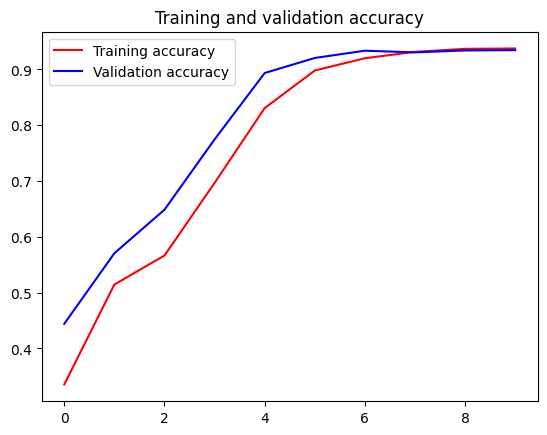

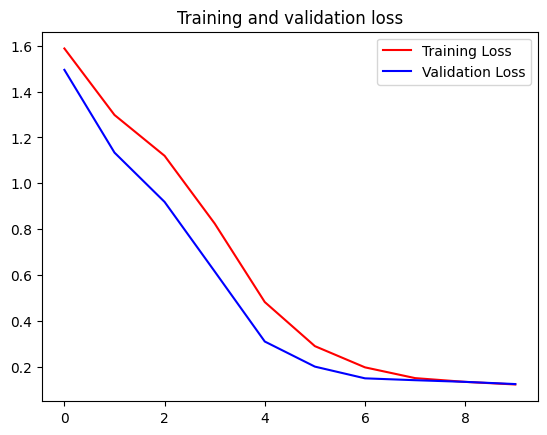

In [59]:
# Visualize Loss & Accuracy

%matplotlib inline
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()

plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [61]:
# Print final metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")


Final Training Accuracy: 0.9375
Final Validation Accuracy: 0.9345
Final Training Loss: 0.1218
Final Validation Loss: 0.1236
